In [40]:
# ============================================================
# CONFIGURATION, IMPORTS ET CHARGEMENT
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("../data/temp_humid_last_synthetic.csv")
TIMESTAMP_COL = "ts"
TEMP_COL = "temperature"
HUMIDITY_COL = "humidity"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable: {DATA_PATH.resolve()}\n"
        "Adapte DATA_PATH au chemin réel du CSV dans ton dépôt."
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Données chargées: {df_raw.shape[0]:,} lignes, {df_raw.shape[1]} colonnes")
print(df_raw.columns.tolist())


Données chargées: 107,060 lignes, 6 colonnes
['id', 'date', 'time', 'temperature', 'humidity', 'ts']


In [41]:
# ============================================================
# VALIDATION DU SCHÉMA ET CONVERSION DES TYPES
# ============================================================
required_cols = {TIMESTAMP_COL, TEMP_COL, HUMIDITY_COL}
missing_cols = required_cols.difference(df_raw.columns)
if missing_cols:
    raise KeyError(f"Colonnes manquantes: {sorted(missing_cols)}")

df = df_raw.copy()
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
df[TEMP_COL] = pd.to_numeric(df[TEMP_COL], errors="coerce")
df[HUMIDITY_COL] = pd.to_numeric(df[HUMIDITY_COL], errors="coerce")

print("Timestamps invalides:", df[TIMESTAMP_COL].isna().sum())
df = df.dropna(subset=[TIMESTAMP_COL])


Timestamps invalides: 0


In [42]:
# ============================================================
# PRÉTRAITEMENT SANS FUITE DE DONNÉES
# ============================================================

# 1) Dédoublonnage: garder la ligne la plus complète pour chaque timestamp.
df["_completeness"] = df[[TEMP_COL, HUMIDITY_COL]].notna().sum(axis=1)
df = (
    df.sort_values([TIMESTAMP_COL, "_completeness"], ascending=[True, False])
      .drop_duplicates(subset=TIMESTAMP_COL, keep="first")
      .drop(columns="_completeness")
      .set_index(TIMESTAMP_COL)
      .sort_index()
)
df.index.name = "ts"

# 2) Détection des coupures de communication et segments continus.
# Un écart supérieur à ~2 min signale une coupure de communication:
# les fenêtres glissantes et les épisodes ne doivent jamais l'enjamber.
EXPECTED_INTERVAL_SECONDS = 120
MAX_CONTINUOUS_GAP_SECONDS = 125

df["gap_seconds"] = df.index.to_series().diff().dt.total_seconds()
df["is_discontinuity"] = (
    df["gap_seconds"].isna()
    | df["gap_seconds"].gt(MAX_CONTINUOUS_GAP_SECONDS)
)
df["segment_id"] = df["is_discontinuity"].cumsum().astype(int)
df["segment_position"] = df.groupby("segment_id").cumcount()

# 3) Split chronologique AVANT le calcul des seuils.
# Les bornes sont dérivées des quantiles temporels pour rester applicables
# même si la plage du fichier change.
unique_days = pd.Series(df.index.normalize().unique()).sort_values().reset_index(drop=True)
if len(unique_days) < 10:
    raise ValueError("Pas assez de jours pour créer train/validation/test.")

train_end_day = unique_days.iloc[int(len(unique_days) * 0.70) - 1]
validation_end_day = unique_days.iloc[int(len(unique_days) * 0.85) - 1]

train_mask = df.index.normalize() <= train_end_day
validation_mask = (
    (df.index.normalize() > train_end_day)
    & (df.index.normalize() <= validation_end_day)
)
test_mask = df.index.normalize() > validation_end_day

df["split"] = np.select(
    [train_mask, validation_mask, test_mask],
    ["train", "validation", "test"],
    default="unassigned",
)

print("Périodes:")
print(" train      :", df.index[train_mask].min(), "→", df.index[train_mask].max())
print(" validation :", df.index[validation_mask].min(), "→", df.index[validation_mask].max())
print(" test       :", df.index[test_mask].min(), "→", df.index[test_mask].max())

# 4) Seuils Tukey calculés UNIQUEMENT sur le train.
# Règle de Tukey: tout ce qui sort de Q1/Q3 +- k*IQR est jugé anormal.
# k = 0.5 / 1.0 / 1.5 donne trois niveaux de sévérité.
def tukey_thresholds(series, mild_factor=0.5, strong_factor=1.0, extreme_factor=1.5):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        raise ValueError("Impossible de calculer les seuils sur une série vide.")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "mild_lower": q1 - mild_factor * iqr,
        "mild_upper": q3 + mild_factor * iqr,
        "strong_lower": q1 - strong_factor * iqr,
        "strong_upper": q3 + strong_factor * iqr,
        "extreme_lower": q1 - extreme_factor * iqr,
        "extreme_upper": q3 + extreme_factor * iqr,
    }

temp_thresholds = tukey_thresholds(df.loc[train_mask, TEMP_COL])
humidity_thresholds = tukey_thresholds(df.loc[train_mask, HUMIDITY_COL])
print("Seuils température (train seulement):", temp_thresholds)
print("Seuils humidité (train seulement):", humidity_thresholds)

# 5) Hystérésis: les épisodes sont redémarrés à chaque segment continu.
# Hystérésis: on entre en épisode dès le franchissement du seuil, mais on
# n'en sort qu'après min_exit_points points repassés sous le seuil.
# Cela évite qu'un capteur qui oscille autour du seuil crée dix épisodes.
def detect_hysteresis(values, enter_threshold, exit_threshold, direction="high", min_exit_points=5):
    episode_ids = pd.Series(0, index=values.index, dtype=int)
    active = False
    exit_count = 0
    episode_id = 0

    for idx, value in values.items():
        if pd.isna(value):
            active = False
            exit_count = 0
            continue

        enter_condition = value >= enter_threshold if direction == "high" else value <= enter_threshold
        exit_condition = value <= exit_threshold if direction == "high" else value >= exit_threshold

        if not active and enter_condition:
            episode_id += 1
            active = True
            exit_count = 0

        if active:
            episode_ids.loc[idx] = episode_id
            if exit_condition:
                exit_count += 1
                if exit_count >= min_exit_points:
                    active = False
                    exit_count = 0
            else:
                exit_count = 0

    return episode_ids


def detect_segmented_episodes(data, value_col, enter_threshold, exit_threshold,
                              direction="high", min_exit_points=5):
    result = pd.Series(0, index=data.index, dtype=int)
    global_episode = 0

    for _, segment in data.groupby("segment_id", sort=True):
        local = detect_hysteresis(
            segment[value_col], enter_threshold, exit_threshold,
            direction=direction, min_exit_points=min_exit_points,
        )
        for local_id in sorted(local[local > 0].unique()):
            global_episode += 1
            result.loc[local.index[local == local_id]] = global_episode
    return result

TEMP_HYSTERESIS_MARGIN = 0.5
HUMIDITY_HYSTERESIS_MARGIN = 2.0

# Références séparées: la définition de y_true est maintenant explicite.
df["episode_id_temp_high"] = detect_segmented_episodes(
    df, TEMP_COL, temp_thresholds["mild_upper"],
    temp_thresholds["mild_upper"] - TEMP_HYSTERESIS_MARGIN, "high"
)
df["episode_id_temp_low"] = detect_segmented_episodes(
    df, TEMP_COL, temp_thresholds["mild_lower"],
    temp_thresholds["mild_lower"] + TEMP_HYSTERESIS_MARGIN, "low"
)
df["episode_id_humidity_high"] = detect_segmented_episodes(
    df, HUMIDITY_COL, humidity_thresholds["mild_upper"],
    humidity_thresholds["mild_upper"] - HUMIDITY_HYSTERESIS_MARGIN, "high"
)
df["episode_id_humidity_low"] = detect_segmented_episodes(
    df, HUMIDITY_COL, humidity_thresholds["mild_lower"],
    humidity_thresholds["mild_lower"] + HUMIDITY_HYSTERESIS_MARGIN, "low"
)

for suffix in ["temp_high", "temp_low", "humidity_high", "humidity_low"]:
    df[f"target_{suffix}"] = (df[f"episode_id_{suffix}"] > 0).astype(int)

df["target_any_environmental"] = df[
    ["target_temp_high", "target_temp_low", "target_humidity_high", "target_humidity_low"]
].max(axis=1)
# Alias conservé uniquement pour compatibilité avec certaines cellules historiques.
df["is_in_anomaly_episode"] = df["target_any_environmental"]

# 6) Features glissantes par segment continu, avec min_periods réaliste.
# Trois horizons, en nombre de points (1 point = 2 min):
# court ~24 min, moyen ~72 min, long ~156 min. min_periods evite de
# calculer une moyenne sur une fenêtre à peine commencée.
window_config = {
    "court": (12, 6),
    "moyen": (36, 18),
    "long": (78, 39),
}

for variable in [TEMP_COL, HUMIDITY_COL]:
    grouped = df.groupby("segment_id")[variable]
    for label, (window, min_periods) in window_config.items():
        df[f"{variable}_mean_{label}"] = grouped.transform(
            lambda s, w=window, mp=min_periods: s.rolling(w, min_periods=mp).mean()
        )
        df[f"{variable}_std_{label}"] = grouped.transform(
            lambda s, w=window, mp=min_periods: s.rolling(w, min_periods=mp).std(ddof=0)
        )
        df[f"segment_freshness_{label}"] = np.minimum(
            df["segment_position"] / max(window - 1, 1), 1.0
        )

# Variations utiles pour les changements rapides.
df["temp_short_long_delta"] = df["temperature_mean_court"] - df["temperature_mean_long"]
df["humidity_short_long_delta"] = df["humidity_mean_court"] - df["humidity_mean_long"]
df["temp_change"] = df.groupby("segment_id")[TEMP_COL].diff()
df["humidity_change"] = df.groupby("segment_id")[HUMIDITY_COL].diff()
df["temp_change_10min"] = df.groupby("segment_id")[TEMP_COL].diff(5)
df["humidity_change_10min"] = df.groupby("segment_id")[HUMIDITY_COL].diff(5)

print("Segments continus:", df["segment_id"].nunique())
print("Répartition des splits:", df["split"].value_counts(), sep="\n")
print("Taux d'anomalie global:", f"{df['target_any_environmental'].mean():.2%}")


Périodes:
 train      : 2025-11-02 15:27:34 → 2026-03-19 23:29:27
 validation : 2026-03-20 00:05:45 → 2026-04-18 23:59:16
 test       : 2026-04-19 00:01:17 → 2026-05-18 19:19:56
Seuils température (train seulement): {'q1': 23.9, 'q3': 25.8, 'iqr': 1.9000000000000021, 'mild_lower': 22.949999999999996, 'mild_upper': 26.75, 'strong_lower': 21.999999999999996, 'strong_upper': 27.700000000000003, 'extreme_lower': 21.049999999999997, 'extreme_upper': 28.650000000000006}
Seuils humidité (train seulement): {'q1': 35.2, 'q3': 40.0, 'iqr': 4.799999999999997, 'mild_lower': 32.800000000000004, 'mild_upper': 42.4, 'strong_lower': 30.400000000000006, 'strong_upper': 44.8, 'extreme_lower': 28.000000000000007, 'extreme_upper': 47.199999999999996}
Segments continus: 1905
Répartition des splits:
split
train         74228
validation    16354
test          16236
Name: count, dtype: int64
Taux d'anomalie global: 35.78%


In [43]:
# ============================================================
# SEGMENTATION BINAIRE (ceci n'est pas PELT)
# Détecte les changements de régime dans la température via la
# minimisation de la SSE. Les sommes cumulées (cs, cs2) permettent
# de calculer la SSE de n'importe quel sous-segment en O(1).
#   - compute_cumsum   : pré-calcule Σx et Σx² cumulés
#   - sse_segment      : SSE d'un segment [start, end)
#   - find_best_split  : meilleur point de coupure (gain de SSE max)
#   - binary_segmentation : méthode gloutonne récursive, distincte de PELT
# ============================================================

def compute_cumsum(signal):
    cs = np.concatenate([[0], np.cumsum(signal)])
    cs2 = np.concatenate([[0], np.cumsum(signal ** 2)])
    return cs, cs2

def sse_segment(cs, cs2, start, end):
    n = end - start
    if n <= 0:
        return 0.0
    s = cs[end] - cs[start]
    s2 = cs2[end] - cs2[start]
    return s2 - (s ** 2) / n

def find_best_split(cs, cs2, start, end, min_size=5):
    total_sse = sse_segment(cs, cs2, start, end)
    best_gain = -np.inf
    best_idx = None
    for i in range(start + min_size, end - min_size):
        gain = total_sse - (sse_segment(cs, cs2, start, i) + sse_segment(cs, cs2, i, end))
        if gain > best_gain:
            best_gain = gain
            best_idx = i
    return best_idx, best_gain

def binary_segmentation(signal, min_size=5, penalty=5.0):
    cs, cs2 = compute_cumsum(signal)
    n = len(signal)
    change_points = []
    stack = [(0, n)]
    while stack:
        start, end = stack.pop()
        if end - start < 2 * min_size:
            continue
        idx, gain = find_best_split(cs, cs2, start, end, min_size)
        if idx is None or gain < penalty:
            continue
        change_points.append(idx)
        stack.append((start, idx))
        stack.append((idx, end))
    return sorted(change_points)

In [44]:
# ============================================================
# APPLICATION DE LA SEGMENTATION BINAIRE PAR SEGMENT CONTINU
# ============================================================
MIN_SEGMENT_LENGTH = 50
BINSEG_PENALTY = 5.0  # À régler sur VALIDATION, jamais sur TEST.

segment_lengths = df.groupby("segment_id").size()
valid_segments = segment_lengths[segment_lengths >= MIN_SEGMENT_LENGTH].index
all_change_points = []

for segment_id in valid_segments:
    segment = df.loc[df["segment_id"] == segment_id, TEMP_COL].dropna()
    if len(segment) < MIN_SEGMENT_LENGTH:
        continue

    signal = segment.to_numpy(dtype=float)
    cs, cs2 = compute_cumsum(signal)
    split_positions = binary_segmentation(
    signal,
    min_size=10,
    penalty=BINSEG_PENALTY,
)
    all_change_points.extend(segment.index[pos] for pos in split_positions)

all_change_points = sorted(set(all_change_points))
print(f"Change points détectés: {len(all_change_points)}")

Change points détectés: 181


In [45]:
# ============================================================
# ATTRIBUTION DES RÉGIMES
# Un nouveau régime commence à une coupure de communication OU à un change point.
# ============================================================
cp_set = set(all_change_points)
df["is_change_point_binseg"] = df.index.to_series().isin(cp_set)
df["starts_new_regime"] = df["is_discontinuity"] | df["is_change_point_binseg"]
df["regime_id"] = df["starts_new_regime"].cumsum().astype(int)

regime_summary = df.groupby("regime_id").agg(
    segment_id=("segment_id", "first"),
    start=(TEMP_COL, lambda s: s.index.min()),
    end=(TEMP_COL, lambda s: s.index.max()),
    mean_temp=(TEMP_COL, "mean"),
    mean_humidity=(HUMIDITY_COL, "mean"),
    n_points=(TEMP_COL, "size"),
)
regime_summary["duration_min"] = (
    regime_summary["end"] - regime_summary["start"]
).dt.total_seconds() / 60


In [46]:
# Aperçu des premiers régimes détectés

print(f"\n[9] Résumé des régimes détectés :\n{regime_summary.head()}")


[9] Résumé des régimes détectés :
           segment_id               start                 end  mean_temp  \
regime_id                                                                  
1                   1 2025-11-02 15:27:34 2025-11-02 15:45:42  24.190000   
2                   2 2025-11-02 16:24:00 2025-11-02 18:14:46  24.346429   
3                   3 2025-11-02 18:51:02 2025-11-02 20:43:50  24.607018   
4                   4 2025-11-02 21:20:06 2025-11-02 23:10:53  24.925000   
5                   5 2025-11-02 23:49:08 2025-11-03 01:39:56  24.921429   

           mean_humidity  n_points  duration_min  
regime_id                                         
1              44.390000        10     18.133333  
2              44.587500        56    110.766667  
3              44.735088        57    112.800000  
4              44.580357        56    110.783333  
5              44.626786        56    110.800000  


In [47]:
# ============================================================
# ANOMALIES ABSOLUES PAR RÉGIME: 4 TYPES SÉPARÉS
# ============================================================
regime_props = df.groupby("regime_id").agg(
    prop_temp_high=(TEMP_COL, lambda s: (s >= temp_thresholds["mild_upper"]).mean()),
    prop_temp_low=(TEMP_COL, lambda s: (s <= temp_thresholds["mild_lower"]).mean()),
    prop_humidity_high=(HUMIDITY_COL, lambda s: (s >= humidity_thresholds["mild_upper"]).mean()),
    prop_humidity_low=(HUMIDITY_COL, lambda s: (s <= humidity_thresholds["mild_lower"]).mean()),
)
regime_summary = regime_summary.join(regime_props)

REGIME_PROP_CUTOFF = 0.40  # À régler sur validation.
for target_name in ["temp_high", "temp_low", "humidity_high", "humidity_low"]:
    regime_summary[f"is_{target_name}_regime"] = (
        regime_summary[f"prop_{target_name}"] >= REGIME_PROP_CUTOFF
    )
    mapping = regime_summary[f"is_{target_name}_regime"].to_dict()
    df[f"pred_binseg_{target_name}"] = df["regime_id"].map(mapping).fillna(False).astype(int)

df["pred_binseg_any"] = df[
    ["pred_binseg_temp_high", "pred_binseg_temp_low", "pred_binseg_humidity_high", "pred_binseg_humidity_low"]
].max(axis=1)


In [48]:
# ============================================================
# ÉVALUATION DE LA SEGMENTATION BINAIRE SUR LE TEST INTACT
# Chaque prédiction est comparée à une référence de même définition.
# ============================================================
def evaluate_binary_target(data, mask, target_col, pred_col, title):
    comparison = data.loc[mask, [target_col, pred_col]].dropna()
    print(f"\n--- {title} ---")
    print(classification_report(
        comparison[target_col].astype(int),
        comparison[pred_col].astype(int),
        digits=3,
        zero_division=0,
    ))
    return comparison

comparison_binseg_temp_high = evaluate_binary_target(
    df, test_mask, "target_temp_high", "pred_binseg_temp_high",
    "Segmentation binaire — température haute"
)
comparison_binseg_any = evaluate_binary_target(
    df, test_mask, "target_any_environmental", "pred_binseg_any",
    "Segmentation binaire — toute anomalie environnementale"
)



--- Segmentation binaire — température haute ---
              precision    recall  f1-score   support

           0      0.999     1.000     1.000     16223
           1      0.000     0.000     0.000        13

    accuracy                          0.999     16236
   macro avg      0.500     0.500     0.500     16236
weighted avg      0.998     0.999     0.999     16236


--- Segmentation binaire — toute anomalie environnementale ---
              precision    recall  f1-score   support

           0      0.958     0.995     0.976      8506
           1      0.994     0.951     0.972      7730

    accuracy                          0.974     16236
   macro avg      0.976     0.973     0.974     16236
weighted avg      0.975     0.974     0.974     16236



In [49]:
# ============================================================
# DIAGNOSTIC DES FAUX NÉGATIFS — TEMPÉRATURE HAUTE
# ============================================================
missed_ts = comparison_binseg_temp_high.index[
    (comparison_binseg_temp_high["target_temp_high"] == 1)
    & (comparison_binseg_temp_high["pred_binseg_temp_high"] == 0)
]
missed_regimes = df.loc[missed_ts, "regime_id"].unique()
cols = ["segment_id", "mean_temp", "prop_temp_high", "duration_min", "n_points"]
print(regime_summary.loc[regime_summary.index.isin(missed_regimes), cols]
      .sort_values("prop_temp_high", ascending=False)
      .head(30))


           segment_id  mean_temp  prop_temp_high  duration_min  n_points
regime_id                                                               
1993             1812  25.845455        0.090909     42.316667        22
1853             1683  25.826667        0.066667     28.250000        15


# Sauts relatifs entre régimes voisins

Cette section complète les seuils absolus par des changements de régime. Les comparaisons sont effectuées **uniquement à l’intérieur du même segment continu**, afin de ne pas comparer deux périodes séparées par une coupure de communication.

In [50]:
# ============================================================
# SAUTS RELATIFS ENTRE RÉGIMES VOISINS DU MÊME SEGMENT CONTINU
# ============================================================
new_regime_summary = regime_summary.reset_index().sort_values(
    ["segment_id", "start"]
).reset_index(drop=True)

new_regime_summary["mean_temp_prev_regime"] = (
    new_regime_summary.groupby("segment_id")["mean_temp"].shift(1)
)
new_regime_summary["mean_humidity_prev_regime"] = (
    new_regime_summary.groupby("segment_id")["mean_humidity"].shift(1)
)
new_regime_summary["temp_jump"] = (
    new_regime_summary["mean_temp"] - new_regime_summary["mean_temp_prev_regime"]
)
new_regime_summary["humidity_jump"] = (
    new_regime_summary["mean_humidity"] - new_regime_summary["mean_humidity_prev_regime"]
)

print(new_regime_summary[
    ["segment_id", "mean_temp", "mean_temp_prev_regime", "temp_jump", "duration_min"]
].head(20))


    segment_id  mean_temp  mean_temp_prev_regime  temp_jump  duration_min
0            1  24.190000                    NaN        NaN     18.133333
1            2  24.346429                    NaN        NaN    110.766667
2            3  24.607018                    NaN        NaN    112.800000
3            4  24.925000                    NaN        NaN    110.783333
4            5  24.921429                    NaN        NaN    110.800000
5            6  24.882143                    NaN        NaN    110.800000
6            7  24.714684                    NaN        NaN    112.816667
7            8  24.517857                    NaN        NaN    110.733333
8            9  24.300000                    NaN        NaN    110.733333
9           10  24.159649                    NaN        NaN    112.783333
10          11  24.176786                    NaN        NaN    110.750000
11          12  24.433929                    NaN        NaN    110.750000
12          13  24.536842             

In [51]:
# Régimes triés par saut de température décroissant

print(new_regime_summary[["mean_temp", "mean_temp_prev_regime", "temp_jump", "duration_min"]].sort_values("temp_jump", ascending=False).head(20))

      mean_temp  mean_temp_prev_regime  temp_jump  duration_min
1071  28.700000              26.234375   2.465625     18.133333
426   26.254545              23.866667   2.387879     20.166667
1009  27.187097              24.816000   2.371097     60.416667
403   28.136364              26.025000   2.111364     20.150000
921   25.070000              22.975000   2.095000     18.133333
157   26.246667              24.224390   2.022276     28.216667
149   26.775000              24.790000   1.985000     30.216667
866   27.863636              25.915556   1.948081     20.150000
1852  25.826667              23.882927   1.943740     28.250000
951   25.383333              23.525000   1.858333     70.500000
398   26.000000              24.212000   1.788000     24.183333
145   25.218182              23.471739   1.746443     20.166667
832   28.315385              26.584211   1.731174     24.166667
844   28.488889              26.775000   1.713889     34.233333
1674  24.764706              23.066667  

In [52]:
# Distribution des sauts (statistiques + quantiles) pour calibrer les seuils

print(new_regime_summary["temp_jump"].describe())
print(new_regime_summary["temp_jump"].quantile([0.05,0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    181.000000
mean       0.137156
std        1.299544
min       -4.203788
25%       -1.007918
50%        0.761250
75%        1.040000
max        2.465625
Name: temp_jump, dtype: float64
0.05   -1.837968
0.10   -1.459130
0.25   -1.007918
0.50    0.761250
0.75    1.040000
0.90    1.639589
0.95    1.858333
0.99    2.374453
Name: temp_jump, dtype: float64


In [53]:
# ============================================================
# SEUILS DE SAUT CALCULÉS UNIQUEMENT SUR LES RÉGIMES DU TRAIN
# ============================================================
train_regime_ids = set(df.loc[train_mask, "regime_id"].unique())
train_jumps = new_regime_summary.loc[
    new_regime_summary["regime_id"].isin(train_regime_ids), "temp_jump"
].dropna()

p25_jump, p75_jump = train_jumps.quantile([0.25, 0.75])
iqr_jump = p75_jump - p25_jump

mild_haut = p75_jump + 0.5 * iqr_jump
strong_haut = p75_jump + 1.0 * iqr_jump
extreme_haut = p75_jump + 1.5 * iqr_jump
mild_bas = p25_jump - 0.5 * iqr_jump
strong_bas = p25_jump - 1.0 * iqr_jump
extreme_bas = p25_jump - 1.5 * iqr_jump

print({
    "mild_bas": mild_bas, "strong_bas": strong_bas, "extreme_bas": extreme_bas,
    "mild_haut": mild_haut, "strong_haut": strong_haut, "extreme_haut": extreme_haut,
})


{'mild_bas': -2.047033045977009, 'strong_bas': -3.0761482279693455, 'extreme_bas': -4.105263409961681, 'mild_haut': 2.069427681992336, 'strong_haut': 3.0985428639846724, 'extreme_haut': 4.127658045977009}


In [54]:
# ============================================================
# CLASSIFICATION DE LA SÉVÉRITÉ DE CHAQUE SAUT DE RÉGIME
# ============================================================

def classify_jump_severity(jump, mild_haut, strong_haut, extreme_haut, mild_bas, strong_bas, extreme_bas):
    if pd.isna(jump):
        return "premier_regime"
    elif jump >= extreme_haut:
        return "saut_extreme_haut"
    elif jump >= strong_haut:
        return "saut_fort_haut"
    elif jump >= mild_haut:
        return "saut_modere_haut"
    elif jump <= extreme_bas:
        return "saut_extreme_bas"
    elif jump <= strong_bas:
        return "saut_fort_bas"
    elif jump <= mild_bas:
        return "saut_modere_bas"
    else:
        return "stable"

new_regime_summary["jump_severity"] = new_regime_summary["temp_jump"].apply(
    lambda j: classify_jump_severity(j, mild_haut, strong_haut, extreme_haut, mild_bas, strong_bas, extreme_bas)
)
print(new_regime_summary["jump_severity"].value_counts())

jump_severity
premier_regime      1905
stable               169
saut_modere_haut       5
saut_modere_bas        5
saut_fort_bas          1
saut_extreme_bas       1
Name: count, dtype: int64


In [55]:
# ============================================================
# CRITÈRE COMBINÉ: NIVEAU ABSOLU OU SAUT RELATIF DANS LES DEUX DIRECTIONS
# ============================================================
# NOTE: cette fonction n'est pas appelée par la suite; seul le calcul de
# max_absolute_anomaly_prop ci-dessous est réellement utilisé.
def is_anomalous_combined(row, prop_cutoff=REGIME_PROP_CUTOFF):
    absolute = max(
        row["prop_temp_high"], row["prop_temp_low"],
        row["prop_humidity_high"], row["prop_humidity_low"],
    ) >= prop_cutoff
    return absolute

new_regime_summary["max_absolute_anomaly_prop"] = (
    new_regime_summary[
        [
            "prop_temp_high",
            "prop_temp_low",
            "prop_humidity_high",
            "prop_humidity_low",
        ]
    ].max(axis=1)
)


In [56]:
# Combien de régimes chaque critère (absolu) flague-t-il ?

required_cols = [
    "prop_temp_high",
    "prop_temp_low",
    "prop_humidity_high",
    "prop_humidity_low",
    "jump_severity",
]

missing_cols = [
    col for col in required_cols
    if col not in new_regime_summary.columns
]

if missing_cols:
    raise KeyError(
        f"Colonnes manquantes dans new_regime_summary : {missing_cols}\n"
        f"Colonnes disponibles : {new_regime_summary.columns.tolist()}"
    )

# Maximum proportion d'anomalie parmi les 4 types
new_regime_summary["max_absolute_anomaly_prop"] = (
    new_regime_summary[
        [
            "prop_temp_high",
            "prop_temp_low",
            "prop_humidity_high",
            "prop_humidity_low",
        ]
    ]
    .max(axis=1)
)

REGIME_PROP_CUTOFF = 0.40

n_absolute = (
    new_regime_summary["max_absolute_anomaly_prop"]
    >= REGIME_PROP_CUTOFF
).sum()


n_total = len(new_regime_summary)

print(
    f"Régimes flagués par critère absolu : "
    f"{n_absolute} / {n_total}"
)


Régimes flagués par critère absolu : 636 / 2086
Régimes flagués par critère de saut : 12 / 2086


# Modèle HMM — pipeline reproductible et sans fuite

In [57]:
# Vérification de hmmlearn
try:
    from hmmlearn.hmm import GaussianHMM
    print("hmmlearn disponible")
except ImportError as exc:
    raise ImportError("Installe hmmlearn avec: pip install hmmlearn") from exc


hmmlearn disponible


In [58]:
# Le pipeline HMM réutilise exactement le même dataframe prétraité,
# les mêmes splits et les mêmes références que la segmentation binaire.
df_hmm = df.copy()


In [59]:
# ============================================================
# FEATURES HMM ET CONSTRUCTION CORRECTE DES SÉQUENCES
# ============================================================

# Le HMM observe le niveau brut, les moyennes sur trois horizons, la
# variabilité, les écarts court/long et les vitesses de variation.
feature_cols = [
    "temperature", "humidity",
    "temperature_mean_court", "temperature_mean_moyen", "temperature_mean_long",
    "humidity_mean_court", "humidity_mean_moyen", "humidity_mean_long",
    "temperature_std_court", "humidity_std_court",
    "temp_short_long_delta", "humidity_short_long_delta",
    "temp_change", "humidity_change",
    "temp_change_10min", "humidity_change_10min",
    "segment_freshness_court", "segment_freshness_moyen",
    "segment_freshness_long",
]

X_full = (
    df_hmm[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_index()
)


def prepare_hmm_sequences(
    feature_data,
    source_data,
    min_sequence_length=2
):
    """
    Retourne les observations dans l'ordre chronologique
    ainsi que les longueurs des séquences continues.
    """

    data = feature_data.sort_index().copy()

    # Récupérer segment_id uniquement pour les lignes encore présentes
    source_segment = source_data.loc[data.index, "segment_id"]

    # Calculer les écarts temporels
    time_gap = data.index.to_series().diff().dt.total_seconds()

    starts_new_sequence = (
        time_gap.isna()
        | time_gap.gt(MAX_CONTINUOUS_GAP_SECONDS)
        | source_segment.ne(source_segment.shift())
    )

    sequence_id = starts_new_sequence.cumsum()

    parts = []
    lengths = []

    for _, part in data.groupby(sequence_id, sort=True):
        if len(part) >= min_sequence_length:
            parts.append(part)
            lengths.append(len(part))

    if not parts:
        raise ValueError("Aucune séquence HMM valide.")

    ordered = pd.concat(parts).sort_index()

    if sum(lengths) != len(ordered):
        raise AssertionError(
            "La somme des longueurs HMM ne correspond pas "
            "au nombre d'observations."
        )

    return ordered, lengths


# ------------------------------------------------------------
# ALIGNER LES MASQUES SUR L'INDEX DE X_full
# ------------------------------------------------------------

train_mask_hmm = pd.Series(
    train_mask,
    index=df_hmm.index
).reindex(X_full.index, fill_value=False)

validation_mask_hmm = pd.Series(
    validation_mask,
    index=df_hmm.index
).reindex(X_full.index, fill_value=False)

test_mask_hmm = pd.Series(
    test_mask,
    index=df_hmm.index
).reindex(X_full.index, fill_value=False)


# ------------------------------------------------------------
# CRÉATION DES JEUX HMM
# ------------------------------------------------------------

X_train, lengths_train = prepare_hmm_sequences(
    X_full.loc[train_mask_hmm],
    df_hmm
)

X_validation, lengths_validation = prepare_hmm_sequences(
    X_full.loc[validation_mask_hmm],
    df_hmm
)

X_test, lengths_test = prepare_hmm_sequences(
    X_full.loc[test_mask_hmm],
    df_hmm
)


print(
    "Dimensions:",
    X_train.shape,
    X_validation.shape,
    X_test.shape
)

print(
    "Séquences:",
    len(lengths_train),
    len(lengths_validation),
    len(lengths_test)
)

assert sum(lengths_train) == len(X_train)
assert sum(lengths_validation) == len(X_validation)
assert sum(lengths_test) == len(X_test)

Dimensions: (23936, 19) (5278, 19) (5276, 19)
Séquences: 1315 290 289


In [60]:
# Répartition des références par split
reference_cols = [
    "target_temp_high", "target_temp_low",
    "target_humidity_high", "target_humidity_low",
    "target_any_environmental",
]
print(df_hmm.groupby("split")[reference_cols].mean().round(4))


            target_temp_high  target_temp_low  target_humidity_high  \
split                                                                 
test                  0.0008           0.0667                0.4753   
train                 0.1613           0.0363                0.1140   
validation            0.0000           0.3406                0.1768   

            target_humidity_low  target_any_environmental  
split                                                      
test                     0.0005                    0.4761  
train                    0.1099                    0.3225  
validation               0.0042                    0.4003  


In [61]:
# Important: les anciens splits v2/v3/v4 ont été supprimés.
# Ils sélectionnaient des fenêtres après inspection des anomalies et rendaient
# la performance optimiste. Les variables train_mask/validation_mask/test_mask
# définies avant les seuils sont désormais les seules utilisées.


In [62]:
# Résumé mensuel des anomalies proxy (utile uniquement pour le diagnostic,
# pas pour modifier le split après coup).
monthly_anomalies = df_hmm.groupby(df_hmm.index.to_period("M"))["target_any_environmental" ].agg(
    total_points="size", anomaly_points="sum"
)
monthly_anomalies["pct_anomalies"] = (
    100 * monthly_anomalies["anomaly_points"] / monthly_anomalies["total_points"]
)
print(monthly_anomalies)


TypeError: Must provide 'func' or tuples of '(column, aggfunc).

In [63]:
# Répartition hebdomadaire — diagnostic seulement
weekly_anomalies = df_hmm.groupby(df_hmm.index.to_period("W"))["target_any_environmental"].agg(
    total_points="size", anomaly_points="sum"
)
weekly_anomalies["pct_anomalies"] = (
    100 * weekly_anomalies["anomaly_points"] / weekly_anomalies["total_points"]
)
print(weekly_anomalies[weekly_anomalies["anomaly_points"] > 0])


                       total_points  anomaly_points  pct_anomalies
ts                                                                
2025-10-27/2025-11-02           185             185     100.000000
2025-11-03/2025-11-09          3819            3319      86.907567
2025-11-10/2025-11-16          3825            1451      37.934641
2025-11-17/2025-11-23          3817            1261      33.036416
2025-11-24/2025-11-30          3812             598      15.687303
2025-12-01/2025-12-07          3820             105       2.748691
2025-12-08/2025-12-14          3819             165       4.320503
2025-12-15/2025-12-21          3813            2139      56.097561
2025-12-22/2025-12-28          3818            1486      38.920901
2025-12-29/2026-01-04          3212               2       0.062267
2026-01-05/2026-01-11          3818            2264      59.298062
2026-01-12/2026-01-18          3823            2504      65.498300
2026-01-19/2026-01-25          3828            2790      72.88

In [64]:
# Résumé des épisodes de température haute
hot_episode_summary = (
    df_hmm[df_hmm["episode_id_temp_high"] > 0]
    .groupby("episode_id_temp_high")
    .agg(
        start=(TEMP_COL, lambda s: s.index.min()),
        end=(TEMP_COL, lambda s: s.index.max()),
        max_temp=(TEMP_COL, "max"),
        n_points=(TEMP_COL, "size"),
    )
)
hot_episode_summary["duration_min"] = (
    hot_episode_summary["end"] - hot_episode_summary["start"]
).dt.total_seconds() / 60
print(hot_episode_summary.sort_values("duration_min", ascending=False).head(15))


                                   start                 end  max_temp  \
episode_id_temp_high                                                     
141                  2026-01-12 12:31:07 2026-01-12 14:24:03      27.1   
149                  2026-01-13 05:51:14 2026-01-13 07:44:08      27.1   
123                  2026-01-10 15:56:48 2026-01-10 17:49:41      27.1   
133                  2026-01-11 16:42:02 2026-01-11 18:34:55      27.4   
91                   2025-12-25 09:27:28 2025-12-25 11:20:20      27.8   
81                   2025-12-24 08:42:21 2025-12-24 10:35:12      28.1   
53                   2025-12-20 05:39:55 2025-12-20 07:32:46      27.3   
54                   2025-12-20 08:09:01 2025-12-20 10:01:52      27.3   
267                  2026-02-07 15:59:10 2026-02-07 17:52:01      28.0   
92                   2025-12-25 11:56:37 2025-12-25 13:49:28      27.7   
98                   2026-01-08 02:02:52 2026-01-08 03:55:42      27.7   
274                  2026-02-26 23:00:

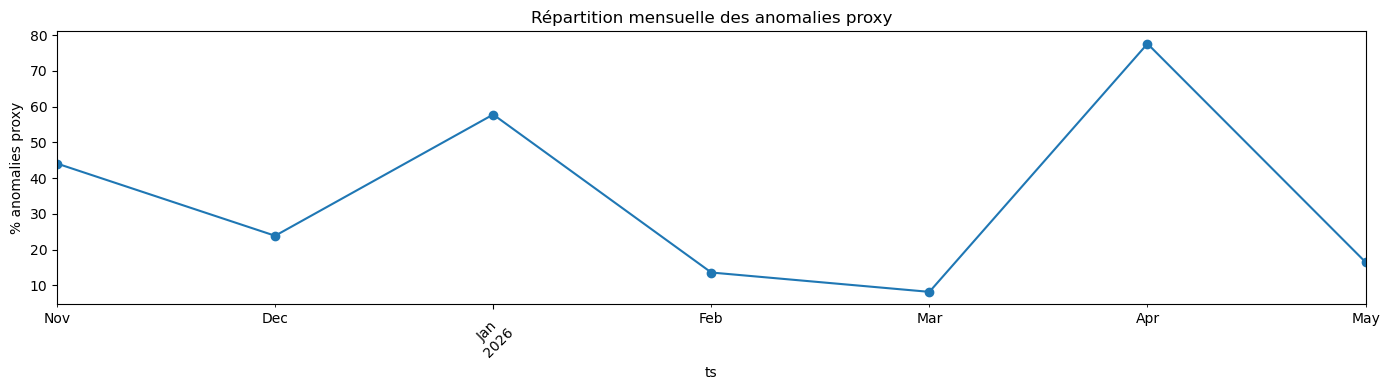

In [65]:
# Visualisation diagnostique
monthly_anomalies["pct_anomalies"].plot(figsize=(14, 4), marker="o")
plt.ylabel("% anomalies proxy")
plt.title("Répartition mensuelle des anomalies proxy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [66]:
# Aucun ajustement du split n'est effectué après cette visualisation.
# Toute décision de modèle sera prise sur la validation uniquement.


In [67]:
# Les anciens objets X_train_v4 / X_test_v4 sont volontairement supprimés.
# Utiliser uniquement: X_train, X_validation, X_test.


In [68]:
# Vérifications de séparation temporelle
assert X_train.index.max() < X_validation.index.min()
assert X_validation.index.max() < X_test.index.min()
print("Séparation chronologique validée.")


Séparation chronologique validée.


In [69]:
# ============================================================
# STANDARDISATION ET ENTRAÎNEMENT HMM STABLE (PLUSIEURS SEEDS)
# ============================================================
scaler_hmm = StandardScaler()
X_train_scaled = scaler_hmm.fit_transform(X_train)
X_validation_scaled = scaler_hmm.transform(X_validation)
X_test_scaled = scaler_hmm.transform(X_test)


# L'EM du HMM converge vers un optimum local qui dépend de l'initialisation.
# On entraîne donc plusieurs graines et on garde le meilleur modèle CONVERGÉ,
# ce qui rend le résultat reproductible d'une exécution à l'autre.
def fit_best_hmm(X, lengths, n_components, seeds=(0, 7, 21, 42, 99), n_iter=500):
    best_model = None
    best_score = -np.inf
    diagnostics = []

    for seed in seeds:
        model = GaussianHMM(
            n_components=n_components,
            covariance_type="diag",
            n_iter=n_iter,
            tol=1e-4,
            random_state=seed,
        )
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(X, lengths=lengths)
            score = model.score(X, lengths=lengths)
            converged = bool(model.monitor_.converged)
            diagnostics.append({"seed": seed, "score": score, "converged": converged})
            if converged and score > best_score:
                best_model = model
                best_score = score
        except Exception as exc:
            diagnostics.append({"seed": seed, "score": np.nan, "converged": False, "error": str(exc)})

    if best_model is None:
        raise RuntimeError(f"Aucun HMM convergé pour K={n_components}. Diagnostics: {diagnostics}")
    return best_model, pd.DataFrame(diagnostics)


In [70]:
# ============================================================
# INTERPRÉTATION DES ÉTATS ET NOMBRE DE PARAMÈTRES BIC
# ============================================================
def build_state_stats(index, states, source_df):
    interp = source_df.loc[index, [TEMP_COL, HUMIDITY_COL]].copy()
    interp["state"] = states
    stats = interp.groupby("state").apply(
        lambda g: pd.Series({
            "n_points": len(g),
            "mean_temp": g[TEMP_COL].mean(),
            "temp_p95": g[TEMP_COL].quantile(0.95),
            "mean_humidity": g[HUMIDITY_COL].mean(),
            "prop_temp_high": (g[TEMP_COL] >= temp_thresholds["mild_upper"]).mean(),
            "prop_temp_low": (g[TEMP_COL] <= temp_thresholds["mild_lower"]).mean(),
            "prop_humidity_high": (g[HUMIDITY_COL] >= humidity_thresholds["mild_upper"]).mean(),
            "prop_humidity_low": (g[HUMIDITY_COL] <= humidity_thresholds["mild_lower"]).mean(),
        })
    )
    return interp, stats


def hmm_parameter_count(n_states, n_features):
    return (
        (n_states - 1)
        + n_states * (n_states - 1)
        + n_states * n_features
        + n_states * n_features
    )


In [71]:
# ============================================================
# SÉLECTION SUR VALIDATION UNIQUEMENT
# ============================================================
validation_results = []
hmm_experiments = {}

# Double boucle: nombre d'états du HMM x seuil de conversion état -> anomalie.
# Tout est mesuré sur la VALIDATION, le test reste intact.
for n_states in [2, 3, 4, 5, 6]:
    model_k, convergence_k = fit_best_hmm(
        X_train_scaled, lengths_train, n_components=n_states
    )
    train_states_k = model_k.predict(X_train_scaled, lengths=lengths_train)
    validation_states_k = model_k.predict(X_validation_scaled, lengths=lengths_validation)

    train_interp_k, train_state_stats_k = build_state_stats(
        X_train.index, train_states_k, df_hmm
    )

    # On teste les règles de conversion état -> anomalie sur VALIDATION.
    for prop_cutoff in [0.05, 0.10, 0.20, 0.30]:
        anomalous_states_k = train_state_stats_k.index[
            train_state_stats_k[
                ["prop_temp_high", "prop_temp_low", "prop_humidity_high", "prop_humidity_low"]
            ].max(axis=1) >= prop_cutoff
        ].tolist()

        y_val = df_hmm.loc[X_validation.index, "target_any_environmental"].astype(int)
        pred_val = pd.Series(
            np.isin(validation_states_k, anomalous_states_k).astype(int),
            index=X_validation.index,
        )
        report = classification_report(y_val, pred_val, output_dict=True, zero_division=0)
        anomaly_metrics = report.get("1", {"precision": 0, "recall": 0, "f1-score": 0})

        validation_results.append({
            "n_states": n_states,
            "prop_cutoff": prop_cutoff,
            "precision": anomaly_metrics["precision"],
            "recall": anomaly_metrics["recall"],
            "f1": anomaly_metrics["f1-score"],
            "converged": model_k.monitor_.converged,
            "min_state_size": int(train_state_stats_k["n_points"].min()),
        })

    # BIC = -2*log-vraisemblance + k*log(n): pénalise les modèles trop riches.
    log_likelihood = model_k.score(X_train_scaled, lengths=lengths_train)
    n_params = hmm_parameter_count(n_states, X_train_scaled.shape[1])
    bic = -2 * log_likelihood + n_params * np.log(len(X_train_scaled))

    hmm_experiments[n_states] = {
        "model": model_k,
        "convergence": convergence_k,
        "train_states": train_states_k,
        "validation_states": validation_states_k,
        "train_state_stats": train_state_stats_k,
        "bic": bic,
    }

validation_results = pd.DataFrame(validation_results).sort_values(
    ["f1", "precision", "recall"], ascending=False
)
print(validation_results.head(15))


    n_states  prop_cutoff  precision    recall        f1  converged  \
16         6         0.05   0.576019  0.881603  0.696779       True   
17         6         0.10   0.711240  0.668488  0.689202       True   
18         6         0.20   0.711240  0.668488  0.689202       True   
19         6         0.30   0.711240  0.668488  0.689202       True   
8          4         0.05   0.481954  0.893898  0.626256       True   
12         5         0.05   0.481146  0.894809  0.625796       True   
13         5         0.10   0.536319  0.692623  0.604531       True   
14         5         0.20   0.536319  0.692623  0.604531       True   
15         5         0.30   0.536319  0.692623  0.604531       True   
9          4         0.10   0.533521  0.692168  0.602577       True   
10         4         0.20   0.533521  0.692168  0.602577       True   
11         4         0.30   0.533521  0.692168  0.602577       True   
0          2         0.05   0.416067  1.000000  0.587637       True   
1     

In [72]:
# ============================================================
# CHOIX DE LA CONFIGURATION — BASÉ EXCLUSIVEMENT SUR VALIDATION
# ============================================================
stable_candidates = validation_results[
    (validation_results["converged"])
    & (validation_results["min_state_size"] >= 20)
]
if stable_candidates.empty:
    raise RuntimeError("Aucune configuration HMM suffisamment stable.")

best_config = stable_candidates.iloc[0]
BEST_N_STATES = int(best_config["n_states"])
BEST_PROP_CUTOFF = float(best_config["prop_cutoff"])

print("Configuration choisie:")
print(best_config)
print("BIC du modèle choisi:", hmm_experiments[BEST_N_STATES]["bic"])

Configuration choisie:
n_states                 6
prop_cutoff           0.05
precision         0.576019
recall            0.881603
f1                0.696779
converged             True
min_state_size          23
Name: 16, dtype: object
BIC du modèle choisi: 13912.369204459748


In [73]:
# ============================================================
# RÉENTRAÎNEMENT SUR TRAIN + VALIDATION, PUIS TEST FINAL UNE SEULE FOIS
# ============================================================
X_trainval_raw = pd.concat([X_train, X_validation]).sort_index()
X_trainval, lengths_trainval = prepare_hmm_sequences(X_trainval_raw, df_hmm)

scaler_final = StandardScaler()
X_trainval_scaled = scaler_final.fit_transform(X_trainval)
X_test_scaled_final = scaler_final.transform(X_test)

hmm_final, final_convergence = fit_best_hmm(
    X_trainval_scaled,
    lengths_trainval,
    n_components=BEST_N_STATES,
)

trainval_states = hmm_final.predict(X_trainval_scaled, lengths=lengths_trainval)
test_states_final = hmm_final.predict(X_test_scaled_final, lengths=lengths_test)

trainval_interp, trainval_state_stats = build_state_stats(
    X_trainval.index, trainval_states, df_hmm
)

anomalous_states_final = trainval_state_stats.index[
    trainval_state_stats[
        ["prop_temp_high", "prop_temp_low", "prop_humidity_high", "prop_humidity_low"]
    ].max(axis=1) >= BEST_PROP_CUTOFF
].tolist()

pred_hmm_test = pd.Series(
    np.isin(test_states_final, anomalous_states_final).astype(int),
    index=X_test.index,
    name="pred_hmm_any",
)
df_hmm.loc[pred_hmm_test.index, "hmm_state_final"] = test_states_final
df_hmm.loc[pred_hmm_test.index, "pred_hmm_any"] = pred_hmm_test

y_test = df_hmm.loc[X_test.index, "target_any_environmental"].astype(int)
print("États anormaux finaux:", anomalous_states_final)
print(trainval_state_stats)
print("\nÉvaluation finale sur test intact:")
print(classification_report(y_test, pred_hmm_test, digits=3, zero_division=0))


États anormaux finaux: [0, 1, 3, 5]
       n_points  mean_temp  temp_p95  mean_humidity  prop_temp_high  \
state                                                                 
0       10066.0  23.757997   24.8000      41.031135        0.000000   
1        3996.0  26.766742   27.7000      33.339139        0.510761   
2        2790.0  24.267778   25.5000      38.659677        0.000717   
3          22.0  25.038682   27.1321      25.104545        0.272727   
4       10129.0  24.673314   26.1000      36.359335        0.004936   
5        2211.0  24.588964   27.7000      39.090592        0.106739   

       prop_temp_low  prop_humidity_high  prop_humidity_low  
state                                                        
0           0.142857            0.244387           0.000000  
1           0.000000            0.000000           0.432432  
2           0.016846            0.020430           0.000000  
3           0.000000            0.000000           1.000000  
4           0.018561   

In [74]:
# Inspection des erreurs sur le test final
hmm_errors = df_hmm.loc[X_test.index, [
    TEMP_COL, HUMIDITY_COL, "target_any_environmental", "pred_hmm_any", "hmm_state_final"
]].copy()
hmm_errors["error_type"] = np.select(
    [
        (hmm_errors["target_any_environmental"] == 1) & (hmm_errors["pred_hmm_any"] == 0),
        (hmm_errors["target_any_environmental"] == 0) & (hmm_errors["pred_hmm_any"] == 1),
    ],
    ["false_negative", "false_positive"],
    default="correct",
)
print(hmm_errors[hmm_errors["error_type"] != "correct"].head(30))

                     temperature  humidity  target_any_environmental  \
ts                                                                     
2026-04-25 19:49:13         24.8      46.8                         1   
2026-04-25 19:51:14         25.4      47.4                         1   
2026-04-25 19:53:15         25.7      46.7                         1   
2026-04-25 19:55:16         26.0      46.2                         1   
2026-04-25 19:57:18         26.4      44.5                         1   
2026-04-25 19:59:19         26.7      43.3                         1   
2026-04-25 20:01:20         26.9      42.2                         1   
2026-04-25 20:03:21         26.6      41.6                         1   
2026-04-26 03:33:15         24.8      46.0                         1   
2026-04-26 03:35:16         24.4      47.2                         1   
2026-04-26 03:37:16         24.1      47.9                         1   
2026-04-26 03:39:17         24.0      48.6                      

In [75]:
# ============================================================
# MÉTRIQUES PAR ÉPISODE (PLUS PROCHES DU COÛT DES VISITES)
# ============================================================
def predicted_episode_ids(prediction, source_df):
    pred = prediction.reindex(source_df.index, fill_value=0).astype(int)
    boundaries = (
        pred.ne(pred.shift(fill_value=0))
        | source_df["segment_id"].ne(source_df["segment_id"].shift())
    )
    ids = boundaries.cumsum()
    return ids.where(pred.eq(1), 0)


def episode_metrics(y_true, y_pred, source_df):
    eval_df = source_df.loc[y_true.index, ["segment_id"]].copy()
    eval_df["true"] = y_true.astype(int)
    eval_df["pred"] = y_pred.astype(int)
    eval_df["true_episode"] = predicted_episode_ids(eval_df["true"], eval_df)
    eval_df["pred_episode"] = predicted_episode_ids(eval_df["pred"], eval_df)

    true_ids = [i for i in eval_df["true_episode"].unique() if i != 0]
    pred_ids = [i for i in eval_df["pred_episode"].unique() if i != 0]

    detected_true = sum(
        eval_df.loc[eval_df["true_episode"] == episode_id, "pred"].any()
        for episode_id in true_ids
    )
    false_pred = sum(
        not eval_df.loc[eval_df["pred_episode"] == episode_id, "true"].any()
        for episode_id in pred_ids
    )
    test_days = max((eval_df.index.max() - eval_df.index.min()).total_seconds() / 86400, 1)

    return {
        "true_episodes": len(true_ids),
        "detected_true_episodes": int(detected_true),
        "episode_recall": detected_true / len(true_ids) if true_ids else np.nan,
        "predicted_episodes": len(pred_ids),
        "false_predicted_episodes": int(false_pred),
        "false_alert_episodes_per_day": false_pred / test_days,
    }

print(episode_metrics(y_test, pred_hmm_test, df_hmm))


{'true_episodes': 146, 'detected_true_episodes': 146, 'episode_recall': np.float64(1.0), 'predicted_episodes': 209, 'false_predicted_episodes': 59, 'false_alert_episodes_per_day': 1.9800241909735197}


In [76]:
# Limite méthodologique importante
print(
    "Les cibles utilisées ici sont des labels proxy générés par seuils Tukey + hystérésis. "
    "Les métriques mesurent donc l'accord avec ces règles, et non la détection vérifiée "
    "d'incidents réels. Pour une évaluation opérationnelle, il faut relier les épisodes "
    "aux alarmes, interventions et diagnostics techniciens."
)


Les cibles utilisées ici sont des labels proxy générés par seuils Tukey + hystérésis. Les métriques mesurent donc l'accord avec ces règles, et non la détection vérifiée d'incidents réels. Pour une évaluation opérationnelle, il faut relier les épisodes aux alarmes, interventions et diagnostics techniciens.


In [77]:
# ============================================================
# COMPARAISON OPTIONNELLE: HMM SIMPLIFIÉ À 2 FEATURES
# ============================================================
simple_cols = ["temperature", "humidity"]
X_simple_full = df_hmm[simple_cols].dropna().sort_index()

# Aligner les masques sur l'index de X_simple_full (après dropna)
train_mask_simple = pd.Series(
    train_mask, index=df_hmm.index
).reindex(X_simple_full.index, fill_value=False)
validation_mask_simple = pd.Series(
    validation_mask, index=df_hmm.index
).reindex(X_simple_full.index, fill_value=False)

X_simple_train, lengths_simple_train = prepare_hmm_sequences(
    X_simple_full.loc[train_mask_simple], df_hmm
)
X_simple_validation, lengths_simple_validation = prepare_hmm_sequences(
    X_simple_full.loc[validation_mask_simple], df_hmm
)

simple_scaler = StandardScaler()
X_simple_train_scaled = simple_scaler.fit_transform(X_simple_train)
X_simple_validation_scaled = simple_scaler.transform(X_simple_validation)

simple_model, simple_convergence = fit_best_hmm(
    X_simple_train_scaled, lengths_simple_train, n_components=BEST_N_STATES
)
simple_train_states = simple_model.predict(
    X_simple_train_scaled, lengths=lengths_simple_train
)
simple_validation_states = simple_model.predict(
    X_simple_validation_scaled, lengths=lengths_simple_validation
)

simple_interp, simple_state_stats = build_state_stats(
    X_simple_train.index, simple_train_states, df_hmm
)
simple_anomalous_states = simple_state_stats.index[
    simple_state_stats[
        ["prop_temp_high", "prop_temp_low", "prop_humidity_high", "prop_humidity_low"]
    ].max(axis=1) >= BEST_PROP_CUTOFF
].tolist()

simple_pred_validation = pd.Series(
    np.isin(simple_validation_states, simple_anomalous_states).astype(int),
    index=X_simple_validation.index,
)
simple_y_validation = df_hmm.loc[X_simple_validation.index, "target_any_environmental"].astype(int)
print(classification_report(
    simple_y_validation, simple_pred_validation, digits=3, zero_division=0
))


IndexError: Boolean index has wrong length: 106818 instead of 106743

In [39]:
# ============================================================
# BASELINE MÉTIER DIRECTE — NE PAS CONVERTIR UN ÉTAT ENTIER VIA SA MOYENNE
# ============================================================
TECHNICIAN_TEMP_HIGH = 27.0
TECHNICIAN_TEMP_LOW = temp_thresholds["mild_lower"]

# Une règle métier directe s'applique au point mesuré, pas à la moyenne d'un état HMM.
df_hmm["pred_business_rule"] = (
    (df_hmm[TEMP_COL] >= TECHNICIAN_TEMP_HIGH)
    | (df_hmm[TEMP_COL] <= TECHNICIAN_TEMP_LOW)
    | (df_hmm[HUMIDITY_COL] >= humidity_thresholds["mild_upper"])
    | (df_hmm[HUMIDITY_COL] <= humidity_thresholds["mild_lower"])
).astype(int)


In [40]:
# Évaluation de la baseline métier sur le même test
business_comparison = df_hmm.loc[
    test_mask, ["target_any_environmental", "pred_business_rule"]
].dropna()
print(classification_report(
    business_comparison["target_any_environmental"],
    business_comparison["pred_business_rule"],
    digits=3,
    zero_division=0,
))


              precision    recall  f1-score   support

           0      0.949     1.000     0.974      8506
           1      1.000     0.941     0.970      7730

    accuracy                          0.972     16236
   macro avg      0.975     0.971     0.972     16236
weighted avg      0.974     0.972     0.972     16236



In [42]:
# Contrôle rapide des colonnes disponibles après tous les ajouts.
print(df_hmm.columns.tolist())

['id', 'date', 'time', 'temperature', 'humidity', 'gap_seconds', 'is_discontinuity', 'segment_id', 'segment_position', 'split', 'episode_id_temp_high', 'episode_id_temp_low', 'episode_id_humidity_high', 'episode_id_humidity_low', 'target_temp_high', 'target_temp_low', 'target_humidity_high', 'target_humidity_low', 'target_any_environmental', 'is_in_anomaly_episode', 'temperature_mean_court', 'temperature_std_court', 'segment_freshness_court', 'temperature_mean_moyen', 'temperature_std_moyen', 'segment_freshness_moyen', 'temperature_mean_long', 'temperature_std_long', 'segment_freshness_long', 'humidity_mean_court', 'humidity_std_court', 'humidity_mean_moyen', 'humidity_std_moyen', 'humidity_mean_long', 'humidity_std_long', 'temp_short_long_delta', 'humidity_short_long_delta', 'temp_change', 'humidity_change', 'temp_change_10min', 'humidity_change_10min', 'is_change_point_binseg', 'starts_new_regime', 'regime_id', 'pred_binseg_temp_high', 'pred_binseg_temp_low', 'pred_binseg_humidity_hi

In [43]:
# ============================================================
# COMPARAISON FINALE DES APPROCHES SUR LE MÊME TEST
# ============================================================
def extract_anomaly_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    metrics = report.get("1", {"precision": 0, "recall": 0, "f1-score": 0})
    return {
        "model": model_name,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1-score"],
        "accuracy": report["accuracy"],
    }

common_index = X_test.index
final_comparison = pd.DataFrame([
    extract_anomaly_metrics(
        df_hmm.loc[common_index, "target_any_environmental"].astype(int),
        df_hmm.loc[common_index, "pred_binseg_any"].astype(int),
        "Segmentation binaire — niveaux absolus",
    ),
    extract_anomaly_metrics(
        y_test,
        pred_hmm_test,
        "HMM final",
    ),
    extract_anomaly_metrics(
        df_hmm.loc[common_index, "target_any_environmental"].astype(int),
        df_hmm.loc[common_index, "pred_business_rule"].astype(int),
        "Règle métier directe",
    ),
]).sort_values("f1", ascending=False)

print(final_comparison)
print("\nRappel: l'accuracy est secondaire car les anomalies sont rares.")


                                    model  precision    recall        f1  \
0  Segmentation binaire — niveaux absolus   0.999168  0.931008  0.963884   
2                    Règle métier directe   1.000000  0.920543  0.958628   
1                               HMM final   0.718952  0.989535  0.832817   

   accuracy  
0  0.965883  
2  0.961145  
1  0.805724  

Rappel: l'accuracy est secondaire car les anomalies sont rares.


In [44]:
# Inspection du modèle à 6 états: taille de chaque état et proportion
# d'anomalies qu'il contient, pour vérifier qu'aucun état n'est vide.
stats = hmm_experiments[6]["train_state_stats"]

display(
    stats[
        [
            "n_points",
            "prop_temp_high",
            "prop_temp_low",
            "prop_humidity_high",
            "prop_humidity_low",
        ]
    ].sort_values("n_points")
)

,n_points,prop_temp_high,prop_temp_low,prop_humidity_high,prop_humidity_low
state,,,,,
5,23.0,0.304348,0.000000,0.000000,1.000000
4,3298.0,0.054579,0.031534,0.053669,0.008187
3,3755.0,0.553129,0.000000,0.000000,0.434354
0,5047.0,0.000000,0.089954,0.382604,0.000000
2,5360.0,0.013246,0.000000,0.000000,0.081903
1,6453.0,0.000000,0.009298,0.000000,0.002789


In [45]:
# Matrice de confusion par seuil de conversion.
# ATTENTION: la cellule est incomplète (le corps de la boucle est un '...'),
# donc y_val et pred_val proviennent encore de la dernière itération de la
# cellule de sélection et les deux seuils affichent le même résultat.
from sklearn.metrics import confusion_matrix

for cutoff in [0.05, 0.10]:

    ...
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred_val
    ).ravel()

    print(cutoff)
    print("TP:", tp)
    print("FP:", fp)
    print("FN:", fn)
    print("TN:", tn)

0.05
TP: 1468
FP: 596
FN: 728
TN: 2486
0.1
TP: 1468
FP: 596
FN: 728
TN: 2486


In [46]:
# Statistiques complètes des états du modèle à 6 états.
stats = hmm_experiments[6]["train_state_stats"]

display(
    stats.sort_values("n_points")
)

,n_points,mean_temp,temp_p95,mean_humidity,prop_temp_high,prop_temp_low,prop_humidity_high,prop_humidity_low
state,,,,,,,,
5,23.0,25.276130,29.0014,25.330435,0.304348,0.000000,0.000000,1.000000
4,3298.0,24.618375,26.8000,38.875076,0.054579,0.031534,0.053669,0.008187
3,3755.0,26.839387,27.8000,33.351105,0.553129,0.000000,0.000000,0.434354
0,5047.0,23.919814,24.9000,42.061403,0.000000,0.089954,0.382604,0.000000
2,5360.0,25.528414,26.4000,36.090597,0.013246,0.000000,0.000000,0.081903
1,6453.0,23.971192,24.7000,37.222873,0.000000,0.009298,0.000000,0.002789


In [ ]:
# ============================================================
# TROISIÈME APPROCHE: ISOLATION FOREST
# Modèle non supervisé, entraîné sur les mêmes features et les mêmes
# splits que le HMM, pour que la comparaison finale soit honnête.
# ============================================================
#Isolation Forest
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "temperature",
    "humidity",
    "temperature_mean_court",
    "temperature_mean_moyen",
    "temperature_mean_long",
    "humidity_mean_court",
    "humidity_mean_moyen",
    "humidity_mean_long",
    "temperature_std_court",
    "humidity_std_court",
    "temp_short_long_delta",
    "humidity_short_long_delta",
    "temp_change",
    "humidity_change",
    "temp_change_10min",
    "humidity_change_10min",
    "segment_freshness_court",
    "segment_freshness_moyen",
    "segment_freshness_long",
]

# On repart des matrices déjà construites pour le HMM (mêmes lignes,
# mêmes colonnes), puis on standardise sur le train uniquement.
X_train_if = X_train.copy()
X_validation_if = X_validation.copy()
X_test_if = X_test.copy()

scaler_if = StandardScaler()

X_train_if_scaled = scaler_if.fit_transform(X_train_if)
X_validation_if_scaled = scaler_if.transform(X_validation_if)
X_test_if_scaled = scaler_if.transform(X_test_if)

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import pandas as pd

validation_results_if = {}

# Le seul hyperparamètre réglé ici est la contamination, c'est-à-dire la
# proportion d'anomalies supposée. Réglage sur la VALIDATION.
for contamination in [0.01, 0.02, 0.05, 0.10, 0.15]:

    model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train_if_scaled)

    pred = model.predict(X_validation_if_scaled)

    # IsolationForest:
    #  1 = normal
    # -1 = anomaly

    pred = (pred == -1).astype(int)

    y_val = df_hmm.loc[
        X_validation.index,
        "target_any_environmental"
    ].astype(int)

    report = classification_report(
        y_val,
        pred,
        output_dict=True,
        zero_division=0,
    )

    validation_results_if[contamination] = report["1"]

validation_results_if = (
    pd.DataFrame(validation_results_if)
    .T
    .reset_index()
    .rename(columns={"index": "contamination"})
)

display(validation_results_if)

best_row = validation_results_if.sort_values(
    "f1-score",
    ascending=False
).iloc[0]

BEST_CONTAMINATION = best_row["contamination"]

print(best_row)

# Réentraînement final sur train + validation avec la meilleure
# contamination, puis une seule évaluation sur le test.
X_trainval_if = pd.concat(
    [X_train_if, X_validation_if]
)

scaler_if = StandardScaler()

X_trainval_scaled = scaler_if.fit_transform(X_trainval_if)
X_test_scaled = scaler_if.transform(X_test_if)

iso = IsolationForest(
    n_estimators=300,
    contamination=BEST_CONTAMINATION,
    random_state=42,
    n_jobs=-1,
)

iso.fit(X_trainval_scaled)

pred_test = iso.predict(X_test_scaled)

pred_test = (pred_test == -1).astype(int)

y_test = df_hmm.loc[
    X_test.index,
    "target_any_environmental"
].astype(int)

print(
    classification_report(
        y_test,
        pred_test,
        digits=3,
        zero_division=0,
    )
)

,contamination,precision,recall,f1-score,support
0,0.01,0.983871,0.055556,0.105172,2196.0
1,0.02,0.989691,0.087432,0.160669,2196.0
2,0.05,0.974227,0.172131,0.292570,2196.0
3,0.10,0.921474,0.261840,0.407801,2196.0
4,0.15,0.836782,0.331512,0.474886,2196.0


contamination       0.150000
precision           0.836782
recall              0.331512
f1-score            0.474886
support          2196.000000
Name: 4, dtype: float64
              precision    recall  f1-score   support

           0      0.554     0.995     0.712      2696
           1      0.970     0.162     0.278      2580

    accuracy                          0.588      5276
   macro avg      0.762     0.579     0.495      5276
weighted avg      0.757     0.588     0.500      5276



In [48]:
# Récapitulatif des deux modèles.
# NOTE: les chiffres sont recopiés à la main depuis les sorties ci-dessus;
# ils ne se mettent pas à jour si le notebook est réexécuté.
comparison = pd.DataFrame({
    "Model": ["HMM", "Isolation Forest"],
    "Precision": [0.719, 0.983871],
    "Recall": [0.990, 0.055556],
    "F1": [0.833, 0.105172],
})
comparison.head()

,Model,Precision,Recall,F1
0,HMM,0.719000,0.990000,0.833000
1,Isolation Forest,0.983871,0.055556,0.105172


In [ ]:
# Vérification ponctuelle de la série de température.
df['temperature']

In [52]:
# Résumé mensuel complet des anomalies proxy par rapport à tous les flags
reference_cols = [
    "target_temp_high", "target_temp_low",
    "target_humidity_high", "target_humidity_low",
]

# Créer un résumé mensuel pour chaque flag
monthly_summary = df_hmm.groupby(df_hmm.index.to_period("M")).agg(
    total_points=(reference_cols[0], "size"),
    **{
        f"{col}_count": (col, "sum") for col in reference_cols
    },
    **{
        f"{col}_pct": (col, lambda s: 100 * s.sum() / len(s)) for col in reference_cols
    }
).round(2)

# Réorganiser les colonnes pour une meilleure lisibilité
cols_ordered = ["total_points"]
for col in reference_cols:
    cols_ordered.append(f"{col}_count")
for col in reference_cols:
    cols_ordered.append(f"{col}_pct")

monthly_summary = monthly_summary[cols_ordered]

print("=" * 100)
print("RÉSUMÉ MENSUEL DES ANOMALIES PROXY")
print("=" * 100)
print(monthly_summary)
print("\n")

# Afficher les statistiques globales
print("STATISTIQUES GLOBALES:")
print("-" * 100)
for col in reference_cols:
    total = df_hmm[col].sum()
    pct = 100 * total / len(df_hmm)
    print(f"{col:30} : {total:6.0f} points ({pct:5.2f}%)")


RÉSUMÉ MENSUEL DES ANOMALIES PROXY
         total_points  target_temp_high_count  target_temp_low_count  \
ts                                                                     
2025-11         15458                     124                    150   
2025-12         16309                    3714                     25   
2026-01         16916                    7664                   1103   
2026-02         15204                     470                    708   
2026-03         16891                       0                    712   
2026-04         16337                       8                   6653   
2026-05          9703                       5                      0   

         target_humidity_high_count  target_humidity_low_count  \
ts                                                               
2025-11                        6043                        683   
2025-12                         143                       1301   
2026-01                         584                 

# trying to integrate external temperature

In [15]:
# ============================================================
# PISTE: COMPARER LA TEMPÉRATURE INTERNE À LA TEMPÉRATURE EXTÉRIEURE
# L'idée est d'isoler la part de chaleur due au site lui-même (climatisation
# défaillante, équipement en surcharge) de la part due à la météo.
# ============================================================
test_df = df_hmm.copy()

external_temp = pd.read_csv("..\\data\\blida_temperatures_2min_synthetic.csv")
# La source externe est en UTC: on la ramène à l'heure locale d'Alger.
external_temp["ts"] = pd.to_datetime(external_temp["timestamp"], utc=True).dt.tz_convert("Africa/Algiers")
external_temp = (
    external_temp.rename(columns={"temperature_2m_c": "external_temperature"})
    .set_index("ts")
    .sort_index()
)

# Make sure the notebook index is datetime-like before aligning
# Les deux index doivent être des DatetimeIndex de même fuseau, sinon
# l'alignement lèverait une erreur. Les trois branches couvrent les cas
# naïf/aware dans un sens comme dans l'autre.
if not isinstance(test_df.index, pd.DatetimeIndex):
    test_df.index = pd.to_datetime(test_df.index)

# Align timezones if needed
if getattr(test_df.index, "tz", None) is None and getattr(external_temp.index, "tz", None) is not None:
    test_df.index = test_df.index.tz_localize(external_temp.index.tz)
elif getattr(test_df.index, "tz", None) is not None and getattr(external_temp.index, "tz", None) is None:
    external_temp.index = external_temp.index.tz_localize(None)
elif (
    getattr(test_df.index, "tz", None) is not None
    and getattr(external_temp.index, "tz", None) is not None
    and test_df.index.tz != external_temp.index.tz
):
    test_df.index = test_df.index.tz_convert(external_temp.index.tz)

# method="nearest": à chaque relevé du site on associe la mesure externe
# la plus proche dans le temps, puis on calcule l'écart interne - externe.
external_aligned = external_temp.reindex(test_df.index, method="nearest")
difference_temp = test_df["temperature"] - external_aligned["external_temperature"]

difference_temp.head()

1970-01-01 00:00:00+00:00              6.4
1970-01-01 00:00:00.000000001+00:00    6.4
1970-01-01 00:00:00.000000002+00:00    6.6
1970-01-01 00:00:00.000000003+00:00    6.5
1970-01-01 00:00:00.000000004+00:00    6.5
dtype: float64